In [1]:
from transformers import GPT2LMHeadModel

/opt/anaconda3/envs/build-nanogpt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load pre-trained GPT-2 model from Hugging Face
model_hf = GPT2LMHeadModel.from_pretrained("gpt2") # gpt2=124M , gpt2-xl=1.5B


# Question 1. Load into variable sd_hf the OrderedDict dictionary containing model parameters (all tensors of the model) - consider that the GPT2Model inherits from torch.nn.Module. Then plot all its keys and their shapes.
sd_hf = model_hf.state_dict()

# Print the shape of each parameter tensor in the state dictionary (GPT2 model parameters and related organization)
for k, v in sd_hf.items():
    print(k, v.shape)

transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [3]:
sd_hf["transformer.wpe.weight"].view(-1)[:20] # first 20 values of the positional embeddings (view(-1) flattens the tensor)

tensor([-0.0188, -0.1974,  0.0040,  0.0113,  0.0638, -0.1050,  0.0369, -0.1680,
        -0.0491, -0.0565, -0.0025,  0.0135, -0.0042,  0.0151,  0.0166, -0.1381,
        -0.0063, -0.0461,  0.0267, -0.2042])

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

# Question 2. Visualize positional embeddings as a grayscale image


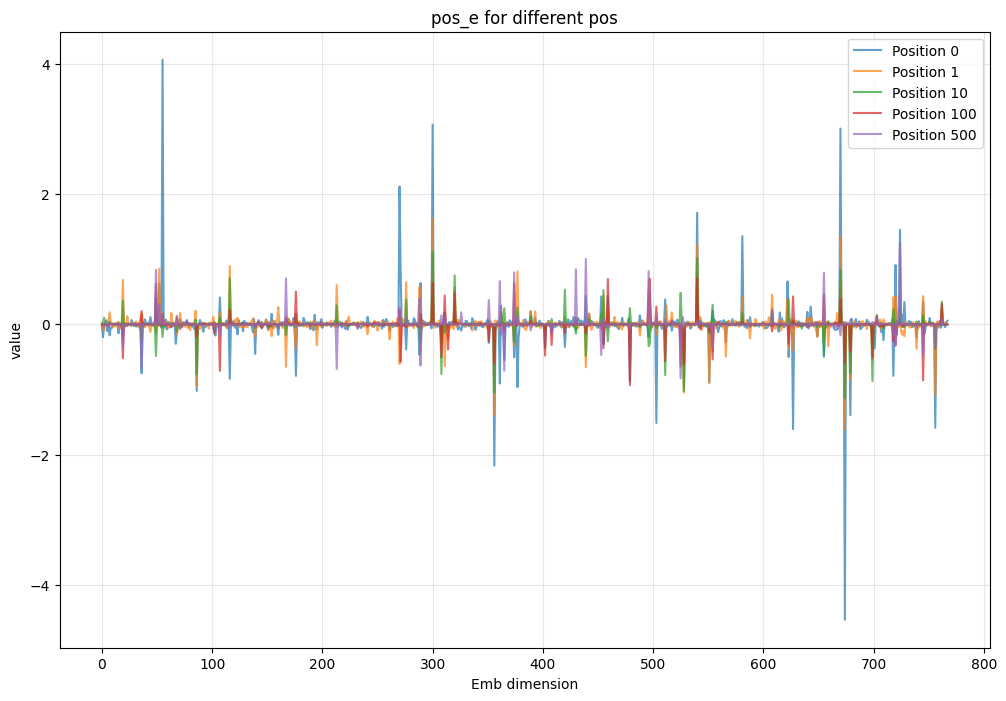

In [7]:
# Question 3. Plot some rows of the positional embeddings

pos_e = sd_hf["transformer.wpe.weight"] #Shape: [1024, 768]

#Plot embeddings for positions 0, 1, 10, 100, 500
positions_to_plot = [0, 1, 10, 100, 500]

plt.figure(figsize=(12, 8))
for pos in positions_to_plot:
    plt.plot(pos_e[pos].numpy(), label=f'Position {pos}', alpha=0.7)

plt.xlabel('Emb dimension')
plt.ylabel('value')
plt.title('pos_e for different pos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


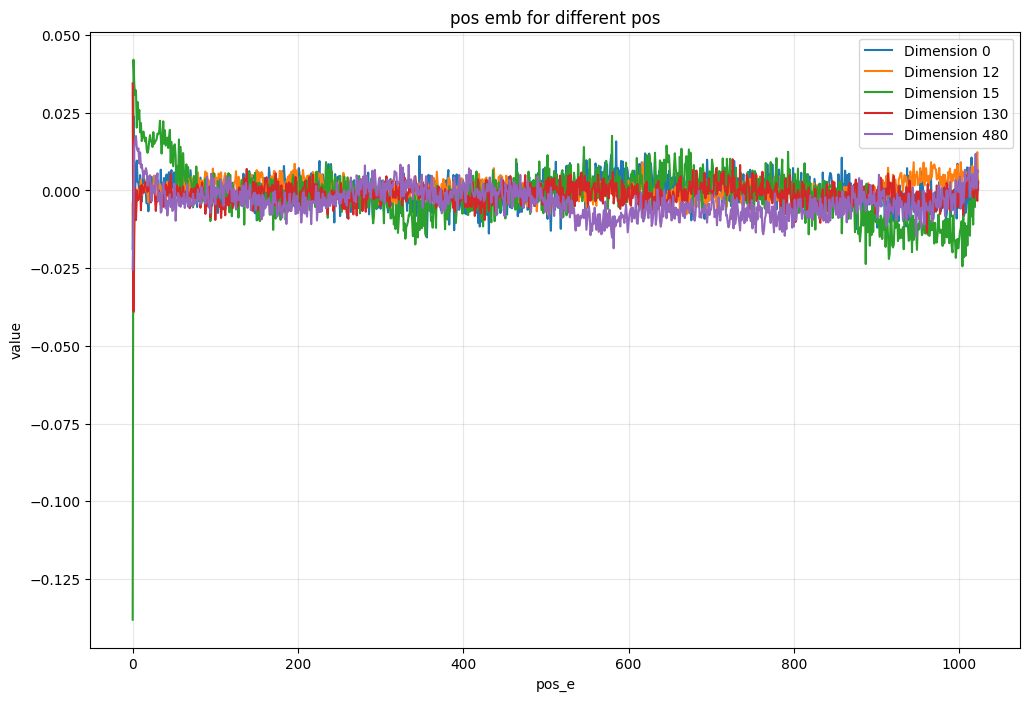

In [15]:
# Question 4. Plot some columns of the positional embeddings

pos_e = sd_hf["transformer.wpe.weight"]

dimensions_to_plot = [0, 12, 15, 130, 480]

plt.figure(figsize=(12, 8))
for dim in dimensions_to_plot:
    plt.plot(pos_e[:, dim].numpy(), label=f'Dimension {dim}')

plt.xlabel('pos_e')
plt.ylabel('value')
plt.title('pos emb for different pos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


W_Q shape: torch.Size([768, 768])
W_K shape: torch.Size([768, 768])
W_V shape: torch.Size([768, 768])


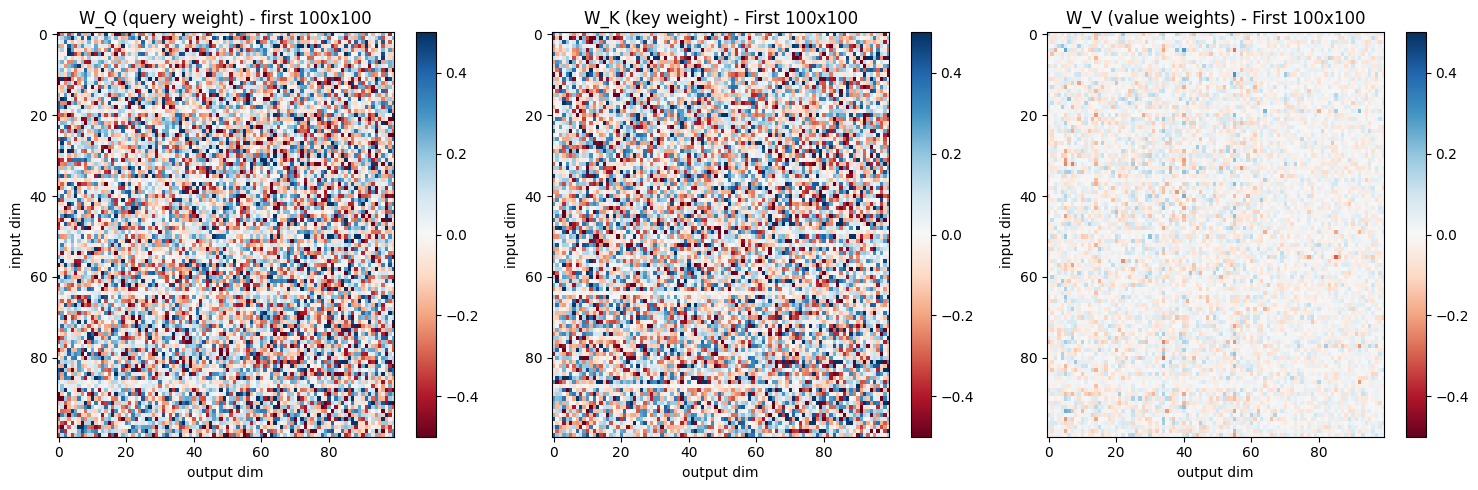

In [12]:
# Question 5: Compare the position (in the overall architecture) of the layer normalization in the Attention is all you need paper [Transformers Paper] and the GPT-2 model. Are them the same?

# Question 6. Visualize part of the attention weights (matrices W_Q, W_K and W_V) of the first attention layer


#5 
# Not the same
# original transformer: post-layer-normalization
# gpt2: pre-layer-normalization


#6 
import torch 

attn_weight = sd_hf["transformer.h.0.attn.c_attn.weight"]


#Split
W_Q = attn_weight[:, :768]
W_K = attn_weight[:, 768:1536]
W_V = attn_weight[:, 1536:] 
print(f"W_Q shape: {W_Q.shape}")
print(f"W_K shape: {W_K.shape}")
print(f"W_V shape: {W_V.shape}")


#visual
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(W_Q[:100, :100].numpy(), cmap='RdBu', aspect='auto', vmin=-0.5, vmax=0.5)
axes[0].set_title('W_Q (query weight) - first 100x100')
axes[0].set_xlabel('output dim')
axes[0].set_ylabel('input dim')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(W_K[:100, :100].numpy(), cmap='RdBu', aspect='auto', vmin=-0.5, vmax=0.5)
axes[1].set_title('W_K (key weight) - First 100x100')
axes[1].set_xlabel('output dim')
axes[1].set_ylabel('input dim')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(W_V[:100, :100].numpy(), cmap='RdBu', aspect='auto', vmin=-0.5, vmax=0.5)
axes[2].set_title('W_V (value weights) - First 100x100')
axes[2].set_xlabel('output dim')
axes[2].set_ylabel('input dim')
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()


In [13]:
# Text generation with Hugging Face GPT-2
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model='gpt2') # pipeline for text generation using GPT-2
set_seed(42)
# Generate 5 sequences of max length 30 starting with the prompt "Hello, I'm a language model,"
generator("Hello, I'm a language model,", max_length=30, num_return_sequences=5)


Device set to use mps:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "Hello, I'm a language model, and my project is based on the idea of a language model.\n\nI want to have a language that's both expressive and readable.\n\nLet's look at the following code:\n\nimport Data.ByteString\n\ndef get ( self ):\n\nself.data = Data.ByteString(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data.get())\n\nself.data.append(data"},
 {'generated_text': "Hello, I'm a language model, not a language model, and if I don't understand it, I won't learn to write it. So I was writing a system for programming in JavaScript and a s

In [14]:
# let's instead sample manually
import torch
from torch.nn import functional as F

model = GPT2LMHeadModel.from_pretrained("gpt2") # 124M
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
# model.to('cuda')
torch.manual_seed(42)
torch.cuda.manual_seed(42)
tokens = [15496, 11, 314, 1101, 257, 3303, 2746, 11] # "Hello, I'm a language model," in GPT-2 token IDs (from Hugging Face tokenizer). Please check it
tokens = torch.tensor(tokens, dtype=torch.long) # (8,)
tokens = tokens.unsqueeze(0).repeat(5, 1) # (5, 8)
x = tokens.to(device)
#x = tokens.to('cuda')

# generate!
while x.size(1) < 30: # max_length=30
    # forward the model to get the logits
    with torch.no_grad():
        logits = model(x)[0] # (B, T, vocab_size)
        # take the logits at the last position
        logits = logits[:, -1, :] # (B, vocab_size)
        # get the probabilities
        probs = F.softmax(logits, dim=-1)
        # do top-k sampling of 50 (huggingface pipeline default)
        # topk_probs here becomes (5, 50), topk_indices is (5, 50)
        topk_probs, topk_indices = torch.topk(probs, 50, dim=-1)
        # select a token from the top-k probabilities
        # note: multinomial does not demand the input to sum to 1
        ix = torch.multinomial(topk_probs, 1) # (B, 1)
        # gather the corresponding indices
        xcol = torch.gather(topk_indices, -1, ix) # (B, 1)
        # append to the sequence
        x = torch.cat((x, xcol), dim=1)

# print the generated text
import tiktoken
enc = tiktoken.get_encoding('gpt2')
for i in range(5):
    tokens = x[i, :30].tolist()
    decoded = enc.decode(tokens)
    print(">", decoded)

> Hello, I'm a language model, not a science. I'm a language designer. I want to write, I want to think. I want
> Hello, I'm a language model, I use an English sentence structure, I like words over sentences.

"That's OK I'll look
> Hello, I'm a language model, not just another language." This isn't a "language model?" It's an idea. So far, what
> Hello, I'm a language model, not a programming model. I'm not a theoretical computer model - you read that right - because my ideas are
> Hello, I'm a language model, I teach myself.

I want to know more about how languages work and why they could be used.
